# Bipartite graph scratch

In [200]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [201]:
import numpy as np
import polars as pl
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import optuna
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data, HeteroData
import networkx as nx
from torch_geometric.utils import to_networkx
import torch
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATv2Conv, to_hetero, RGATConv, HeteroConv, Linear
from sklearn.manifold import TSNE
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from torch.utils.data import DataLoader
from torchvision import transforms
import torch_geometric.transforms as T
import torch_geometric

In [202]:
def visualize_graph(G, color):
    plt.figure(figsize=(7,7))
    plt.xticks([])
    plt.yticks([])
    nx.draw_networkx(G, pos=nx.spring_layout(G, seed=42), with_labels=False,
                     node_color=color, cmap="Set2")
    plt.show()

def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

In [203]:
rna = pl.read_csv("xena_brca_data/TCGA.BRCA.sampleMap_HiSeqV2", separator="\t")

In [204]:
gene_names = rna[:,0]
rna = rna.drop("sample")

In [205]:
# load labels & filter rows with nulls
clinicalMatrix = pl.read_csv("xena_brca_data/TCGA.BRCA.sampleMap_BRCA_clinicalMatrix", separator="\t", infer_schema_length=0)
cM = clinicalMatrix.filter(pl.col("PAM50_mRNA_nature2012") != "null")

In [206]:
labels = cM.select(["sampleID","PAM50_mRNA_nature2012"])
labels = labels.filter(pl.col("PAM50_mRNA_nature2012") != "Normal-like")

In [207]:
y_all = labels["PAM50_mRNA_nature2012"].to_numpy()
# y_all

In [208]:
# display label counts
np.unique(labels["PAM50_mRNA_nature2012"].to_numpy(), return_counts=True)

(array(['Basal-like', 'HER2-enriched', 'Luminal A', 'Luminal B'],
       dtype=object),
 array([ 98,  58, 231, 127]))

In [209]:
rna = rna.select(labels["sampleID"].to_numpy())

In [210]:
# filter low var rows
rna_mat = rna.to_numpy()
rna_vars = rna_mat.var(axis=1)
high_var_mask = rna_vars > 0.1

np.unique(high_var_mask, return_counts=True)

high_var_idx = np.where(high_var_mask)[0]

gene_names = gene_names[high_var_idx]
rna = rna[high_var_idx]

print(rna.shape, gene_names.shape)

(18994, 514) (18994,)


In [211]:
label_encoder = LabelEncoder()
label_encoder.fit(y_all)
y_all_e = label_encoder.transform(y_all)

# add numberd labels to labels df
labels = labels.with_columns(y=y_all_e)

In [212]:
# labels and rna columns are aligned, do train, val, test split

# random split for train / test
train_temp_idx, test_idx = train_test_split(
    np.arange(rna.shape[1]),
    test_size=0.3,
    # stratify=y,
    random_state=4
)

In [213]:
train_idx, val_idx = train_test_split(
    train_temp_idx, 
    test_size=0.1, 
    stratify=y_all_e[train_temp_idx],                   
    random_state=4
)

In [221]:
# split dataframes
train_df = rna[:, train_idx.tolist()]
train_labels = labels[train_idx]
val_df = rna[:, val_idx.tolist()]
val_labels = labels[val_idx]
test_df = rna[:, test_idx.tolist()]
test_labels = labels[test_idx]

In [215]:
# select features based on the training set
# num_labels = len(np.unique(y_all_e))
# genes_class_mean = np.zeros((rna.shape[0], num_labels))

# # separate training samples by class
# for label in range(num_labels):
#     # select cols which are from this class
#     label_samples = train_labels.filter(pl.col("y") == label)["sampleID"].to_numpy()
#     label_train_df = train_df[label_samples].to_numpy()

#     genes_class_mean[:, label] = label_train_df.mean(axis=1)

# genes_class_variance = genes_class_mean.var(axis=1)

# class_var_order = np.argsort(genes_class_variance)

# # select the 500 genes with the largest variance
# genes_to_select = 500
# best_500 = class_var_order >= (genes_class_variance.shape[0] - genes_to_select)
# best_500_idx = np.where(best_500)[0]


# selection itself
train_df = train_df[best_500_idx]
val_df = val_df[best_500_idx]
test_df = test_df[best_500_idx]

In [331]:
best_500_genes = gene_names[best_500_idx].to_numpy()

In [284]:
X_train = train_df.to_numpy().T
y_train = train_labels["y"].to_numpy()
X_val = val_df.to_numpy().T
y_val = val_labels["y"].to_numpy()
X_test = test_df.to_numpy().T
y_test = test_labels["y"].to_numpy()

best_500, best_500_idx = variational_selection(X_train, y_train)

X_train = X_train[:, best_500]
X_val = X_val[:, best_500]
X_test = X_test[:, best_500]

# scale everything
std_scale = StandardScaler().fit(X_train)
X_train = std_scale.transform(X_train) 
X_val = std_scale.transform(X_val)
X_test = std_scale.transform(X_test)

In [280]:
def variational_selection(X_train, y, n_features=500):
    """
    Given training data X_train (n_samples, n_features) and labels y (n_samples,)
    filter the features with class based variance
    """
    # select features based on the training set
    num_labels = len(np.unique(y))
    features_class_mean = np.zeros((X_train.shape[1], num_labels))

    # separate training samples by class
    for label in range(num_labels):
        X_class = X_train[y == label]
        features_class_mean[:, label] = X_class.mean(axis=0)

    feat_class_vars = features_class_mean.var(axis=1)
    class_var_order = np.argsort(feat_class_vars)

    # select the features with the largest variance
    best_mask = class_var_order >= (feat_class_vars.shape[0] - n_features)
    best_idx = np.where(best_mask)[0]

    return best_mask, best_idx

In [285]:
# eval using knns
ks = (1, 30)

# eval on rbf svms
def objective_knn(trial):

    knn = KNeighborsClassifier(
        n_neighbors=trial.suggest_int("n_neighbors", ks[0], ks[1]),
        weights=trial.suggest_categorical("weights", ["uniform", "distance"]),
    )


    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_val)

    f1 = f1_score(y_val, y_pred, average="weighted")

    return f1

study = optuna.create_study(direction="maximize")
study.optimize(objective_knn, n_trials=200)

# print the mean f1 score for the best performing parameter
# print(
#     f"| RBF SVM | {best_results['acc']:.4f} +/- {best_results['acc_std']:.4f} | {best_results['f1_macro']:.4f} +/- {best_results['f1_macro_std']:.4f} | {best_results['f1_weighted']:.4f} +/- {best_results['f1_weighted_std']:.4f} |"
# )
print(f"study {study.best_value=}, {study.best_params=}")

[I 2024-03-20 22:31:26,965] A new study created in memory with name: no-name-72859089-dba4-48e9-9a26-008dc2f715c1
[I 2024-03-20 22:31:26,988] Trial 0 finished with value: 0.6672029172029172 and parameters: {'n_neighbors': 6, 'weights': 'uniform'}. Best is trial 0 with value: 0.6672029172029172.
[I 2024-03-20 22:31:26,992] Trial 1 finished with value: 0.6700757575757577 and parameters: {'n_neighbors': 16, 'weights': 'distance'}. Best is trial 1 with value: 0.6700757575757577.
[I 2024-03-20 22:31:26,996] Trial 2 finished with value: 0.6700757575757577 and parameters: {'n_neighbors': 13, 'weights': 'distance'}. Best is trial 1 with value: 0.6700757575757577.
[I 2024-03-20 22:31:27,001] Trial 3 finished with value: 0.6715399610136452 and parameters: {'n_neighbors': 8, 'weights': 'uniform'}. Best is trial 3 with value: 0.6715399610136452.
[I 2024-03-20 22:31:27,005] Trial 4 finished with value: 0.7493386243386244 and parameters: {'n_neighbors': 3, 'weights': 'uniform'}. Best is trial 4 with

study study.best_value=0.7805555555555556, study.best_params={'n_neighbors': 3, 'weights': 'distance'}


In [286]:
knn = KNeighborsClassifier(
    n_neighbors=study.best_params["n_neighbors"],
    weights=study.best_params["weights"]
)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

f1 = f1_score(y_test, y_pred, average="weighted")

print("knn f1: ", f1)

knn f1:  0.6493733422086564


## KNNs
f1 score of ~0.65

In [287]:
C_range: tuple = (1e-3, 1e3)
gamma_range: tuple = (1e-3, 1e3)

# eval on rbf svms
def objective(trial):

    svm = SVC(
        C=trial.suggest_float("C", C_range[0], C_range[1], log=True),
        gamma=trial.suggest_float(
            "gamma", gamma_range[0], gamma_range[1], log=True
        ),
        class_weight=trial.suggest_categorical("class_weight", ["balanced", None]),
        kernel="rbf",
    )

    svm.fit(X_train, y_train)
    
    y_pred = svm.predict(X_val)

    f1 = f1_score(y_val, y_pred, average="weighted")

    return f1

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200)

# print the mean f1 score for the best performing parameter
# print(
#     f"| RBF SVM | {best_results['acc']:.4f} +/- {best_results['acc_std']:.4f} | {best_results['f1_macro']:.4f} +/- {best_results['f1_macro_std']:.4f} | {best_results['f1_weighted']:.4f} +/- {best_results['f1_weighted_std']:.4f} |"
# )
print(f"study {study.best_value=}, {study.best_params=}")

[I 2024-03-20 22:31:45,443] A new study created in memory with name: no-name-688be1e6-7581-4bf7-abd4-a7ce38b07772
[I 2024-03-20 22:31:45,476] Trial 0 finished with value: 0.1 and parameters: {'C': 0.09028645627127287, 'gamma': 909.3796332596687, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.1.
[I 2024-03-20 22:31:45,495] Trial 1 finished with value: 0.1 and parameters: {'C': 0.3421120991428876, 'gamma': 0.47162398962319013, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.1.
[I 2024-03-20 22:31:45,518] Trial 2 finished with value: 0.2450980392156863 and parameters: {'C': 0.26132161070849946, 'gamma': 376.25294686954464, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.2450980392156863.
[I 2024-03-20 22:31:45,538] Trial 3 finished with value: 0.6503052503052502 and parameters: {'C': 303.06996485791626, 'gamma': 0.005657559050680836, 'class_weight': None}. Best is trial 3 with value: 0.6503052503052502.
[I 2024-03-20 22:31:45,557] Trial 4 finished with va

study study.best_value=0.8855232514461724, study.best_params={'C': 0.7662553517697039, 'gamma': 0.0020462703741553974, 'class_weight': 'balanced'}


In [289]:
# fit model with best params and test on test set
svm = SVC(
        C=study.best_params["C"],
        gamma=study.best_params["gamma"],
        class_weight=study.best_params["class_weight"],
        kernel="rbf",
)

svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

f1 = f1_score(y_test, y_pred, average="weighted")

print("svm f1: ", f1)

svm f1:  0.8273866788593406


## SVMs with rbf kernel
- weighted f1 score with ~0.83 on test set

# Classical neural network

In [290]:
class MyDataset(torch.utils.data.Dataset):
  def __init__(self, X, y, transform=None):
    """
    This function initializes the MyDataset class.

    Args:
        X (np.ndarray): The features (data points).
        y (np.ndarray): The labels (target values).
        transform (torchvision.transforms, optional): A transform to apply to the data. Defaults to None.
    """
    self.X = X
    self.y = y
    self.transform = transform  # Optional transform

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    X_sample = self.X[idx]
    y_sample = self.y[idx]

    # Apply transform if provided
    if self.transform:
      X_sample = self.transform(X_sample)  # Convert to PyTorch tensor

    return X_sample, y_sample

X_train, X_val, X_test = torch.tensor(X_train), torch.tensor(X_val), torch.tensor(X_test)
y_train, y_val, y_test = torch.tensor(y_train), torch.tensor(y_val), torch.tensor(y_test)

# Convert data to torch.float32
X_train = X_train.float()
X_val = X_val.float()
X_test = X_test.float()

# Create datasets with transforms (assuming your data is suitable for ToTensor)
train_dataset = MyDataset(X_train, y_train)
val_dataset = MyDataset(X_val, y_val)
test_dataset = MyDataset(X_test, y_test)

batch_size = 32  # Adjust batch size based on your hardware and data size

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=11)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=11)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=11)

In [291]:
class MLP(torch.nn.Module):
    def __init__(self, input_sz, num_classes, hidden_channels):
        super().__init__()
        torch.manual_seed(12345)
        self.lin1 = Linear(input_sz, hidden_channels)
        self.lin2 = Linear(hidden_channels, num_classes)

    def forward(self, x):
        x = self.lin1(x)
        x = F.relu(x)  # Corrected this line
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin2(x)
        return x

class MLPTrainer(L.LightningModule):  # Fixed the import of LightningModule
    def __init__(self, net):  # Changed 'Net' to 'net'
        super().__init__()
        self.net = net  # Changed 'Net' to 'net'

    def training_step(self, batch, batch_idx):
        x, y = batch
        x = x.view(x.size(0), -1)
        y_pred = self.net(x)
        loss = F.cross_entropy(y_pred, y)  # Changed 'torch.nn.functional' to 'F'
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        x = x.view(x.size(0), -1)
        y_pred = self.net(x)
        val_loss = F.cross_entropy(y_pred, y)  # Changed 'torch.nn.functional' to 'F'
        val_f1 = f1_score(y, y_pred.argmax(dim=1), average='weighted')  # Fixed the calculation of f1_score
        self.log('val_loss', val_loss)
        self.log('val_f1', val_f1)

    def test_step(self, batch, batch_idx):
        x, y = batch
        x = x.view(x.size(0), -1)
        y_pred = self.net(x)
        test_f1 = f1_score(y, y_pred.argmax(dim=1), average='weighted')  # Fixed the calculation of f1_score
        self.log('test_f1', test_f1)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min')
        return {
            "optimizer": optimizer,
            "lr_scheduler_config": {
                "scheduler": scheduler,
                "monitor": "val_loss",
            }
        }
# Assuming X_train, X_val, X_test, y_train, y_val, y_test, train_loader, test_loader are already defined

# Create model instance
model = MLP(
    input_sz=X_train.shape[1],
    num_classes=len(np.unique(y_train)),
    hidden_channels=32
)

# Create LightningModule instance
mlp = MLPTrainer(model)

# Create PyTorch Lightning Trainer
trainer = L.Trainer(
    max_epochs=40,
    log_every_n_steps=1,
    callbacks=[EarlyStopping(monitor="val_loss", mode="min")],
)

# Train the model
trainer.fit(
    model=mlp,
    train_dataloaders=train_loader,  # Fixed the argument name
    val_dataloaders=val_loader  # Added validation data
)

# Test the model
trainer.test(
    model=mlp,
    dataloaders=test_loader  # Fixed the argument name
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/lubojjan/micromamba/envs/diploma/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/home/lubojjan/micromamba/envs/diploma/lib/python3.12/site-packages/lightning/pytorch/core/optimizer.py:376: Found unsupported keys in the optimizer configuration: {'lr_scheduler_config'}

  | Name | Type | Params
------------------------------
0 | net  | MLP  | 16.2 K
------------------------------


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Testing: |                                                                                                    …

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         test_f1            0.7925633192062378
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_f1': 0.7925633192062378}]

## MLP results
so with a simple MLP we get about the same results as with rbf svm, ~
0.835

## Mogonet style gnn

In [294]:
def cosine_similarity_matrix(matrix):
    """
    given a matrix of (n_samples, n_features) compute the cosine similarities, between the samples
    """
    # Compute dot product between all pairs of vectors
    dot_products = np.dot(matrix, matrix.T)
    
    # Compute magnitudes of all vectors
    magnitudes = np.linalg.norm(matrix, axis=1)
    
    # Compute outer product of magnitudes to obtain matrix of magnitudes product
    magnitude_products = np.outer(magnitudes, magnitudes)
    
    # Compute cosine similarity matrix
    cosine_similarities = dot_products / magnitude_products
    
    return cosine_similarities

def keep_n_neighbours(A, n):
      rows, cols = A.shape
      for i in range(rows):
        # Find indices of the k highest elements
        bottom_k_indices = np.argsort(A[i])[:-n]
        # Set all other elements to zero
        A[i][bottom_k_indices] = 0
      return A
    

def dense_to_coo(adj_mat):
    """
    convert an adjacency matrix in a dense format to a torch tensor in COO format
    """
    indices = np.where(adj_mat != 0)
    indices = np.vstack((indices[0], indices[1]))
    return torch.tensor(indices, dtype=torch.int64)
    
def dense_to_attributes(adj_mat):
    """
    return the flattened weight entries from the matrix
    for use as edge attributes
    """
    return torch.tensor(adj_mat[adj_mat != 0]).view(-1,1)
    

In [295]:
from torch_geometric.nn import GCNConv


class GCN(torch.nn.Module):
    def __init__(self, input_sz, n_classes, hidden_channels):
        super().__init__()
        torch.manual_seed(1234567)
        self.conv1 = GCNConv(input_sz, hidden_channels, add_self_loops=False)
        self.conv2 = GCNConv(hidden_channels, n_classes, add_self_loops=False)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class GAT(torch.nn.Module):
    def __init__(self, input_sz, n_classes, hidden_channels, heads):
        super().__init__()
        torch.manual_seed(1234567)
        self.conv1 = GATv2Conv(input_sz, hidden_channels, heads, dropout=0.6, add_self_loops=False)
        self.conv2 = GATv2Conv(hidden_channels * heads, n_classes, heads=1, concat=False, dropout=0.6, add_self_loops=False)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.4, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.4, training=self.training)
        x= self.conv2(x, edge_index)
        return x

In [420]:
# build mogonet style GNN with
# a. thresholded cosine similarity

# transform features to (n_samples, n_features) tensor
X = rna.to_numpy().T
X = X[:, best_500]


# construct adjacency matrix
eps = 0.99
n = 15
A = cosine_similarity_matrix(X)
# A = keep_n_neighbours(A, n)
A[np.abs(A) < eps] = 0

X = std_scale.transform(X)
X = torch.tensor(X, dtype=torch.float32)
print(X.shape)

# construct edge indices
edge_indices = dense_to_coo(A)
print(edge_indices.shape)

# construct training mask
train_mask = np.zeros(X.shape[0], dtype=bool)
train_mask[train_idx] = True
train_mask = torch.tensor(train_mask)

val_mask = np.zeros(X.shape[0], dtype=bool)
val_mask[val_idx] = True
val_mask = torch.tensor(val_mask)

test_mask = np.zeros(X.shape[0], dtype=bool)
test_mask[test_idx] = True
test_mask = torch.tensor(test_mask)

y = torch.tensor(y_all_e, dtype=torch.int64)

data = Data(
    x=X,
    edge_index=edge_indices,
    y=y,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
)

torch.Size([514, 500])
torch.Size([2, 7794])


In [421]:
print(f"num of isolated nodees {np.sum(A.sum(axis=1) == 1)}")

num of isolated nodees 15


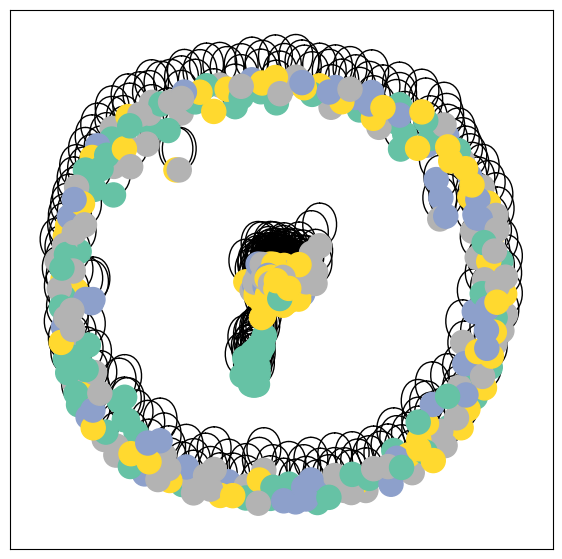

In [422]:
G = to_networkx(data, to_undirected=True)
visualize_graph(G, color=data.y)

In [419]:
# model = GCN(
#     input_sz=X_train.shape[1],
#     n_classes=len(np.unique(y_train)),
#     hidden_channels=32,
# )
model = GAT(
    input_sz=X_train.shape[1],
    n_classes=len(np.unique(y_train)),
    hidden_channels=64,
    heads=2,
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.25)  # Define the learning rate scheduler

def train():
    model.train()
    optimizer.zero_grad()  # Clear gradients.
    out = model(data.x, data.edge_index)  # Perform a single forward pass.
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss

@torch.no_grad()
def test(mask):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)  # Use the class with highest probability.
    test_correct = pred[mask] == data.y[mask]  # Check against ground-truth labels.
    test_f1 = f1_score(pred[mask], data.y[mask], average="weighted")
    test_acc = int(test_correct.sum()) / int(mask.sum())  # Derive ratio of correct predictions.
    return test_acc, test_f1

best_val_f1 = 0

for epoch in range(1, 2001):
    loss = train()
    train_eval = test(data.train_mask)
    val_eval = test(data.val_mask)
    if epoch % 50 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f} Train acc {train_eval[0]:.4f} Train f1 {train_eval[1]:.4f} Val acc {val_eval[0]:.4f} Val f1 {val_eval[1]:.4f}')
        test_acc = test(data.test_mask)
        print(f'Test Accuracy: {test_acc[0]:.4f}, test f1: {test_acc[1]:.4f}')    

print("################################")
test_acc = test(data.test_mask)
print(f'Test Accuracy: {test_acc[0]:.4f}, test f1: {test_acc[1]:.4f}')

Epoch: 050, Loss: 0.7071 Train acc 0.8669 Train f1 0.8684 Val acc 0.8056 Val f1 0.8173
Test Accuracy: 0.7742, test f1: 0.7772
Epoch: 100, Loss: 0.5328 Train acc 0.9133 Train f1 0.9121 Val acc 0.7500 Val f1 0.7654
Test Accuracy: 0.7484, test f1: 0.7444


KeyboardInterrupt: 

## gnn results
- mogonet style with gcn gets ~0.77
- mogonet style with gat gets up to 0.84, depends on params and the graph it gets initialized with, so about the same as rbf svms and mlp
- Best Epoch: **Train acc 0.9969 Train f1 0.9969 Val acc 0.8889 Val f1 0.8940
Test Accuracy: 0.8387, test f1: 0.8407**
- interestingly on regular gcn the thresholded cosine similarity graph works much better than keep n most similar neighbours one even though the graph is a lot more disconnected, with GATs we get about the same performance with both graphs
- the parameters could be tuned with optuna

In [ ]:
# b. moglam style cosine similarity + learned graph

In [ ]:
# c. GAT layers

In [ ]:
# d. GAT layers + moglam style learned graph

In [300]:
def create_expression_connections(X, std_multiplier=1.0):
    """
    This function identifies and categorizes gene expression levels as 
    under-expressed (-1), over-expressed (1), or baseline (0) based on standard 
    deviation from the mean.
    
    Args:
     X (np.ndarray): A 2D NumPy array representing gene expression data, 
         with shape (samples, genes).
     std_multiplier (float, optional): A hyperparameter that scales the 
         standard deviation to define the expression bounds. Higher values will result
         in stricter bounds (std_multiplier=2.0 will consider values further than 2 sigma
         from the mean to be differential) Defaults to 1.0.
    
    Returns:
     np.ndarray: A 2D NumPy array with the same shape as X, where each element 
         indicates the expression category (-1, 0, or 1) for the corresponding 
         gene in each sample.
    """
    mean_exps = X.mean(axis=0)
    exps_std = X.std(axis=0)
    
    lb_exps = mean_exps - exps_std * std_multiplier
    ub_exps = mean_exps + exps_std * std_multiplier
    
    A_exps = np.zeros_like(X)

    mask_below = X <= lb_exps
    mask_above = X >= ub_exps
    
    A_exps[mask_below] = -1  # Set under-expressed elements
    A_exps[mask_above] = 1  # Set over-expressed elements

    return A_exps

In [301]:
# build bipartite graph style GNN

# determine the expression of gene accross the population
# - if the gene is overexpressed for that sample connect with 1
# - if the gene is underexpressed connect with -1
# - else connect with 0
# the over/under expression cutoff is a parameter we will have to tune
# GATv2Conv can use edge attribute vectors, so we can place these into the vectors
# RGAT conv can also use these

# transform features to (n_samples, n_features) tensor
X = rna.to_numpy().T
X = X[:, best_500]
Xn = std_scale.transform(X)
Xt = torch.tensor(X, dtype=torch.float32)
print(X.shape)

(514, 500)


In [361]:
A_exps = create_expression_connections(X, std_multiplier=2.24)

# lets see if all nodes are connected
Asums = np.abs(A_exps).sum(axis=1)
# print(Asums)
print("isolated samples:", Asums[Asums == 0])
# lets see if all nodes are connected
Asums = np.abs(A_exps).sum(axis=0)
# print(Asums)
print("isolated nodes:", Asums[Asums == 0])
# we can see that the first gene doesnt have much of an differential expression
mean_connections = np.abs(A_exps).sum(axis=1)
# print("degrees:", mean_connections)
print("mean degree:", mean_connections.mean())

isolated samples: [0. 0.]
isolated nodes: [0. 0. 0.]
mean degree: 15.490272373540856


# note about params
- with default multiplier of 1.0 we have a pretty dense network with mean degree ~131
- with 2.0 we get a much sparser network with mean degree of ~23 and still no isolated nodes

In [362]:
# get interactions
from bipartite_gnn.preprocessing import get_gene_gene_interactions

In [363]:
interact_df = get_gene_gene_interactions(best_500_genes)

In [364]:
interactions = interact_df.select(['Official Symbol Interactor A', 'Official Symbol Interactor B'])

In [365]:
interaction_matrix = np.eye(len(best_500_genes))
gene_idx_dict = {elem: idx for idx, elem in enumerate(best_500_genes)}
nfc = 0

for i in range(interactions.shape[0]):
    ia = interactions[i, 0]
    ib = interactions[i, 1]

    if ia == 'HSPA1B':
        ia = 'HSPA1A'
    if ib == 'HSPA1B':
        ib = 'HSPA1A'

    if ia == 'H3F3A':
        ia = 'H3F3B'
    if ib == 'H3F3A':
        ib = 'H3F3B'

    if ia == 'SMN2':
        ia = 'SMN1'
    if ib == 'SMN2':
        ib = 'SMN1'

    if ia == 'DEFA1':
        ia = 'DEFA1B'
    if ib == 'DEFA1':
        ib = 'DEFA1B'

    if ia == 'SPCS2':
        ia = 'SPC25'
    if ib == 'SPCS2':
        ib = 'SPC25'

    if ia == 'SLURP1':
        ia = 'ARSB'
    if ib == 'SLURP1':
        ib = 'ARSB'
    
    # try match a
    ia_idx = gene_idx_dict.get(ia)
    if ia_idx is None:
        aliases = interact_df[i, 'Synonyms Interactor A'].split('|')
        for a in aliases:
            ia_idx = gene_idx_dict.get(a)
            if ia_idx is not None:
                break
        if not ia_idx:
            print(f'{ia} interactor not found in input, ignoring')
            nfc += 1
            continue
    # try match b
    ib_idx = gene_idx_dict.get(ib)
    if ib_idx is None:
        aliases = interact_df[i, 'Synonyms Interactor B'].split('|')
        for a in aliases:
            ib_idx = gene_idx_dict.get(a)
            if ib_idx is not None:
                break
        if not ib_idx:
            print(f'{ib} interactor not found in input, ignoring')
            nfc += 1
            continue
        
    interaction_matrix[ia_idx,ib_idx] = 1
    interaction_matrix[ib_idx,ia_idx] = 1

interaction_connections = dense_to_coo(interaction_matrix)
print(nfc)

0


In [366]:
sample_to_gene_connections = dense_to_coo(A_exps)
# sample_to_gene_connections = torch_geometric.utils.add_self_loops(sample_to_gene_connections)[0]

In [367]:
sample_to_gene_connections.shape

torch.Size([2, 7962])

In [449]:
# create a heterodata object with two types of nodes
# TODO ADD AND USE EDGE ATTRIBUTES
data = HeteroData()
data['sample'].x=Xt
data['sample'].y=y
data['sample'].train_mask=train_mask
data['sample'].val_mask=val_mask
data['sample'].test_mask=test_mask
data['feature'].x=torch.ones(Xt.shape[1], Xt.shape[1]) # <- set initial gene features to ones
data['sample', 'connected_to', 'feature'].edge_index=sample_to_gene_connections
data['sample', 'connected_to', 'feature'].edge_attributes=dense_to_attributes(A_exps)
data['feature', 'interacts_with', 'feature'].edge_index=interaction_connections
data['sample', 'similar_to', 'sample'].edge_index=dense_to_coo(torch.eye(Xt.shape[0]))
# data['feature', 'interacts_with', 'feature'].edge_attr= ...
data = T.ToUndirected()(data) # add backward features
# data = T.AddSelfLoops()(data)

In [450]:
data

HeteroData(
  sample={
    x=[514, 500],
    y=[514],
    train_mask=[514],
    val_mask=[514],
    test_mask=[514],
  },
  feature={ x=[500, 500] },
  (sample, connected_to, feature)={
    edge_index=[2, 7962],
    edge_attributes=[7962, 1],
  },
  (feature, interacts_with, feature)={ edge_index=[2, 1928] },
  (sample, similar_to, sample)={ edge_index=[2, 514] },
  (feature, rev_connected_to, sample)={
    edge_index=[2, 7962],
    edge_attributes=[7962, 1],
  }
)

In [465]:
class BiGAT_2L(torch.nn.Module):
    def __init__(self, input_sz, n_classes, channels, heads):
        super().__init__()
        torch.manual_seed(1234567)
        self.conv1 = GATv2Conv(input_sz, channels, heads, dropout=0.1, add_self_loops=False)
        self.conv2 = GATv2Conv(channels * heads, n_classes, heads=1, concat=False, dropout=0.1, add_self_loops=False)

    def forward(self, x, edge_index):
        # x = F.dropout(x, p=0.0, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        # x = F.dropout(x, p=0.0, training=self.training)
        x = self.conv2(x, edge_index)
        return x


class BiGAT_3L(torch.nn.Module):
    def __init__(self, input_sz, n_classes, channels, heads, proj_dim=100):
        super().__init__()
        torch.manual_seed(1234567)

        self.mrna_proj = torch.nn.Linear(data.shape[1], proj_dim)
        
        self.conv1 = GATv2Conv(input_sz * proj_dim, channels, heads, dropout=0.1, add_self_loops=False)
        self.conv2 = GATv2Conv(channels * heads, channels, heads, dropout=0.1, add_self_loops=False)
        self.conv3 = GATv2Conv(channels * heads, n_classes, heads=1, concat=False, dropout=0.1, add_self_loops=False)

    def forward(self, x, edge_index):

        x = self.mrna_proj(x)
        # x = F.dropout(x, p=0.1, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        # x = F.dropout(x, p=0.1, training=self.training)
        x = F.elu(self.conv2(x, edge_index))
        # x = F.dropout(x, p=0.1, training=self.training)
        x = self.conv3(x, edge_index)
        return x

class RBiGAT(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels, num_layers):
        super().__init__()
        # first layer
        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv({
                ('sample', 'connected_to', 'feature'): GATv2Conv((-1, -1), hidden_channels, dropout=0.9, add_self_loops=False),
                ('sample', 'rev_connected_to', 'feature'): GATv2Conv((-1, -1), hidden_channels, dropout=0.9, add_self_loops=False),
                ('feature', 'interacts_with', 'feature'): GATv2Conv((-1, -1), hidden_channels, dropout=0.9, add_self_loops=False),
                ('sample', 'similar_to', 'sample'): GCNConv(-1, hidden_channels),
            }, aggr='sum')
            self.convs.append(conv)

        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        
        for conv in self.convs:
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return self.lin(x_dict['sample'])

In [463]:
data['sample'].x

tensor([[ 7.6497,  9.1372, 11.3388,  ...,  8.4743, 10.0915,  3.8312],
        [ 7.2327, 10.5142,  8.7716,  ...,  8.5336, 10.4175,  4.0124],
        [ 8.6363,  8.3852, 10.8024,  ...,  8.3991, 10.7437,  3.4741],
        ...,
        [ 8.0962, 10.2685,  8.4005,  ...,  8.9706,  9.8254,  4.2534],
        [ 6.7602,  8.5837, 10.6842,  ...,  8.3920,  9.8871,  3.8604],
        [ 9.4947, 10.6535,  9.1192,  ...,  9.3664, 10.3406,  4.9280]])

In [468]:
data.x_dict.keys()

dict_keys(['sample', 'feature'])

In [466]:
# using the previously defined network on this graph
# model = BiGAT_2L(
#     input_sz=X_train.shape[1],
#     n_classes=len(np.unique(y_train)),
#     channels=64,
#     heads=2,
# )
model = BiGAT_3L(
    input_sz=X_train.shape[1],
    n_classes=len(np.unique(y_train)),
    channels=32,
    heads=1,
)

# model = RBiGAT(
#     hidden_channels=32,
#     out_channels=len(np.unique(y_train)),
#     num_layers=3
# )

optimizer = torch.optim.Adam(model.parameters(), lr=0.0004, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

def train():
    model.train()
    optimizer.zero_grad()  # Clear gradients.
    out = model(data.x_dict, data.edge_index_dict) # ['sample']  # Perform a single forward pass.
    mask = data['sample'].train_mask
    loss = criterion(out[mask], data['sample'].y[mask])  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss

@torch.no_grad()
def test(mask):
    model.eval()
    out = model(data.x_dict, data.edge_index_dict) # ['sample']
    pred = out.argmax(dim=1)  # Use the class with highest probability.
    test_correct = pred[mask] == data['sample'].y[mask]  # Check against ground-truth labels.
    test_f1 = f1_score(pred[mask], data['sample'].y[mask], average="weighted")
    test_acc = int(test_correct.sum()) / int(mask.sum())  # Derive ratio of correct predictions.
    return test_acc, test_f1

best_val_f1 = 0

for epoch in range(1, 501):
    loss = train()
    train_eval = test(data['sample'].train_mask)
    val_eval = test(data['sample'].val_mask)
    if epoch % 10 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f} Train acc {train_eval[0]:.4f} Train f1 {train_eval[1]:.4f} Val acc {val_eval[0]:.4f} Val f1 {val_eval[1]:.4f}')
        test_acc = test(data['sample'].test_mask)
        print(f'Test Accuracy: {test_acc[0]:.4f}, test f1: {test_acc[1]:.4f}')    

print("################################")
test_acc = test(data['sample'].test_mask)
print(f'Test Accuracy: {test_acc[0]:.4f}, test f1: {test_acc[1]:.4f}')

AttributeError: 'NodeStorage' object has no attribute 'shape'

# bipartite model results
without interactions it reaches 
- acc 0.47, f1 0.62 w self-loops
- acc 0.51, f1 0.64 w/o self-loops

2 layer gat with interactions and self-loops reaches
- up to acc 0.83, f1 0.83
- **Best Epoch** Train acc 0.9938 Train f1 0.9938 Val acc 0.8611 Val f1 0.8724
Test Accuracy: 0.8194, test f1: 0.8316

3 layer relational gat with interactions and self-loops can get reliably to something like
- Epoch: 280, Loss: 0.0937 Train acc 0.9907 Train f1 0.9907 Val acc 0.8611 Val f1 0.8657
Test Accuracy: 0.8323, test f1: 0.8341
- Epoch: 480, Loss: 0.0148 Train acc 1.0000 Train f1 1.0000 Val acc 0.8333 Val f1 0.8424
Test Accuracy: 0.8516, test f1: 0.8533


4 layer relational gat works well too
- Epoch: 140, Loss: 0.0868 Train acc 0.9876 Train f1 0.9876 Val acc 0.8611 Val f1 0.8634
Test Accuracy: 0.8323, test f1: 0.8325


## notes:
- ones in feature vectors seem to be better than zeros
- self loops seem to help too
- not really a big difference between 3 layer and 2 layer architecture, though 3 layer should work better from theoretical prespective as all LSPs in the graph should be 3 hops
- using more dropout in the architecture could be potentially benefitial but it takes longer to learn with that
- edge attributes dont seem to cause a big difference
- bipartite architecture seems to learn slower than mogonet-type architecture, but reaches similar performance
- relational bipartite architecture learns fast and reaches similar or better performance

In [ ]:
# a. w interactions

In [ ]:
# b. w/o interactions

In [ ]:
# bipartite style model with 2 different relations
# - sample-feature or feature-sample
# - feature-feature

In [ ]:
# eval mogonet style model


In [ ]:
# eval bipartite style model
